<a href="https://colab.research.google.com/github/marottiluc/Single_Lens_Fitting_LM/blob/main/rmdc2026_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading light curves from the 2026 Roman Data Challenge

### Downloading the light curve

you will need to pip install huggingface_hub pyarrow fastparquet for this to work

In [1]:
!pip install mulensmodel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.3 MB/s eta 0:00:00


In [2]:
# Run this cell if you are using Google Colab
!pip install pyLIMA

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.2/448.2 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.5 MB/s eta 0:00:

In [4]:
# system imports
import os
import time
import sys
from pathlib import Path

# data access imports
from huggingface_hub import hf_hub_download
import pandas as pd


# data analysis/visualization imports
import numpy as np
import matplotlib.pyplot as plt

#pyLIMA needs
from pyLIMA import event, telescopes
from pyLIMA.models import PSPL_model, FSPL_model
from pyLIMA.fits import LM_fit, DE_fit, MCMC_fit, TRF_fit
from pyLIMA.outputs import pyLIMA_plots

import MulensModel as mm

In [5]:
!pip install fastparquet pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.3 MB/s eta 0:00:00


In [6]:
TIER = "Beginner"
EVENT_ID =  "RMDC26_000001" # example event ID for the Experienced and Beginner Tiers.
# You will need to change this to the event you want to work with.
# Valid event IDs are from RMDC26_000001 to RMDC26_000188 for the Beginner Tier.
REPO_ID = f"RGES-PIT/{TIER}"
if TIER in ["Beginner", "Experienced"]:
    FILENAME = f"RMDC26_{TIER}_Tier_test.parquet"  # "_test" tells hugging face this is not a machine learning training set.
    local_data_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME, repo_type="dataset")
    lc_data_all = pd.read_parquet(local_data_path, engine="fastparquet", columns=["name", "bjd", "mag", "mag_err", "filt"], filters=[("filt", "==", "F146")])
    if EVENT_ID not in lc_data_all["name"].unique():
        raise ValueError(f"Event ID {EVENT_ID} not found in the Hugging Face {TIER} tier dataset.")

    #start of loop
    lc_data = lc_data_all[lc_data_all["name"] == EVENT_ID].copy()
else:
    raise ValueError(f"Unsupported tier for alternate data access: {TIER}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


RMDC26_Beginner_Tier_test.parquet:   0%|          | 0.00/165M [00:00<?, ?B/s]

In [7]:
# Get unique bands (`observatory_code` or `filt`)
bands = np.sort(np.unique(lc_data["filt"].to_numpy()))
print(f"Bands found: {bands}")
band = 'F146'


Bands found: ['F087' 'F146' 'F213']


In [36]:
event_ids = lc_data_all["name"].unique()
all_fit_results = [] # Initialize list to store results

for x in range(112,118):
    lc_data = lc_data_all[lc_data_all["name"] == event_ids[x]]

    # Re-create the mask inside the loop for the current lc_data
    mask = lc_data["filt"] == band

    # Create a new event
    Roman_event = event.Event()
    Roman_event.name = f'rmdc_event'

    # Create telescope object
    lightcurve_data = np.column_stack(
        [
            lc_data['bjd'][mask],
            lc_data['mag'][mask],
            lc_data['mag_err'][mask]
            ]
        )
    Roman_W149 = telescopes.Telescope(
        name='Roman_W149',
        camera_filter='H',
        lightcurve=lightcurve_data.astype(float),
        lightcurve_names=['time', 'mag', 'err_mag'],
        lightcurve_units=['HJD', 'mag', 'mag']
    )

    # Add telescope to event
    Roman_event.telescopes.append(Roman_W149)

    # Set survey telescope (for alignment)
    Roman_event.find_survey('Roman')

    # Check event setup
    Roman_event.check_event()

    print(f"Event '{Roman_event.name}' created with {len(Roman_event.telescopes)} telescope(s)")
    print(f"Data points: {len(Roman_W149.lightcurve)}")

    # Create PSPL model
    pspl = PSPL_model.PSPLmodel(Roman_event)

    # Initialize fit with Levenberg-Marquardt algorithm
    my_fit = LM_fit.LMfit(pspl)

    # Run the fit
    print("\nRunning LM fit...")
    my_fit.fit()
    # my_fit.fit_outputs()

    # Display results
    print("\nEvent Name: ")
    print(event_ids[x])
    print("\nFit Results:")
    # Ensure 'best_model' is an OrderedDict to access named parameters
    model_outputs = my_fit.fit_results['best_model']

    # Store results for the current event
    event_results = {
        'event_id': event_ids[x],
        't0': float(model_outputs[0]),
        'u0': float(model_outputs[1]),
        'tE': float(model_outputs[2]),
        'fsource_Roman_W149': float(model_outputs[3]),
        'ftotal_Roman_W149': float(model_outputs[4]),
        'chi2': float(my_fit.fit_results['chi2']),
        'reduced_chi2': float (my_fit.fit_results['chi2'] / (len(lc_data['bjd']) - 5))
    }
    all_fit_results.append(event_results)

    print(model_outputs)
    print(f"\nChi-squared: {my_fit.fit_results['chi2']:.2f}")
    delta_chi2 = my_fit.fit_results['chi2'] - (len(lc_data['bjd']) - 5)
    print(f"Delta Chi-squared: {delta_chi2:.2f}")
    print("Reduced Chi-squared: ", my_fit.fit_results['chi2'] / (len(lc_data['bjd']) - 5))
    print("t_E:")
    print(model_outputs[2])

    print(event_results)



check_event  : Everything looks fine...
Event 'rmdc_event' created with 1 telescope(s)
Data points: 46208

Running LM fit...
Selecting Roman_W149 to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2461872.3702916997, 0.5, 285.46018236673746, 122.505115552893, 1398.2481974956643]
fit  : Levenberg-Marquardt fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2461872.238343358)),
             ('u0', np.float64(-0.40691958007114165)),
             ('tE', np.float64(25.90767413483269)),
             ('fsource_Roman_W149', np.float64(256.105319726346)),
             ('ftotal_Roman_W149', np.float64(1410.6792730081534)),
             ('chi2', np.float64(46410.54665375106))])

Event Name: 
RMDC26_000113

Fit Results:
[ 2.46187224e+06 -4.06919580e-01  2.59076741e+01  2.56105320e+02
  1.41067927e+03]

Chi-squared: 46410.55
Delta Chi-squared: -2680.45
Reduced Chi-squared:  0.9453982736907184
t_E:
25.90767413483269
{'event_id': 'RMDC26_000113', 't0': 2461

In [26]:
event_ids = lc_data_all["name"].unique()
all_fit_results = [] # Initialize list to store results

for x in range(112,119):
    lc_data = lc_data_all[lc_data_all["name"] == event_ids[x]]

    # Re-create the mask inside the loop for the current lc_data
    mask = lc_data["filt"] == band

    # Create a new event
    Roman_event = event.Event()
    Roman_event.name = f'rmdc_event'

    # Create telescope object
    lightcurve_data = np.column_stack(
        [
            lc_data['bjd'][mask],
            lc_data['mag'][mask],
            lc_data['mag_err'][mask]
            ]
        )
    Roman_W149 = telescopes.Telescope(
        name='Roman_W149',
        camera_filter='H',
        lightcurve=lightcurve_data.astype(float),
        lightcurve_names=['time', 'mag', 'err_mag'],
        lightcurve_units=['HJD', 'mag', 'mag']
    )

    # Add telescope to event
    Roman_event.telescopes.append(Roman_W149)

    # Set survey telescope (for alignment)
    Roman_event.find_survey('Roman')

    # Check event setup
    Roman_event.check_event()

    print(f"Event '{Roman_event.name}' created with {len(Roman_event.telescopes)} telescope(s)")
    print(f"Data points: {len(Roman_W149.lightcurve)}")

    # Create PSPL model
    pspl = PSPL_model.PSPLmodel(Roman_event)

    # Initialize fit with Levenberg-Marquardt algorithm
    my_fit = LM_fit.LMfit(pspl)

    # Run the fit
    print("\nRunning LM fit...")
    my_fit.fit()
    # my_fit.fit_outputs()

    # Display results
    print("\nEvent Name: ")
    print(event_ids[x])
    print("\nFit Results:")
    # Ensure 'best_model' is an OrderedDict to access named parameters
    model_outputs = my_fit.fit_results['best_model']

    # Store results for the current event
    event_results = {
        'event_id': event_ids[x],
        't0': float(model_outputs[0]),
        'u0': float(model_outputs[1]),
        'tE': float(model_outputs[2]),
        'fsource_Roman_W149': float(model_outputs[3]),
        'ftotal_Roman_W149': float(model_outputs[4]),
        'chi2': float(my_fit.fit_results['chi2']),
        'reduced_chi2': float (my_fit.fit_results['chi2'] / (len(lc_data['bjd']) - 5))
    }
    all_fit_results.append(event_results)

    # Rewrite the saving function to save data as a txt file with two columns
    with open(f'{event_ids[x]}.txt', 'w') as f:
        f.write("Parameter\tValue\n") # Write header
        for key, value in event_results.items():
            f.write(f"{key}\t{value}\n")


check_event  : Everything looks fine...
Event 'rmdc_event' created with 1 telescope(s)
Data points: 46208

Running LM fit...
Selecting Roman_W149 to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2461872.3702916997, 0.5, 285.46018236673746, 122.505115552893, 1398.2481974956643]
fit  : Levenberg-Marquardt fit SUCCESS
best model:
OrderedDict([('t0', np.float64(2461872.238343358)),
             ('u0', np.float64(-0.40691958007114165)),
             ('tE', np.float64(25.90767413483269)),
             ('fsource_Roman_W149', np.float64(256.105319726346)),
             ('ftotal_Roman_W149', np.float64(1410.6792730081534)),
             ('chi2', np.float64(46410.54665375106))])

Event Name: 
RMDC26_000113

Fit Results:
check_event  : Everything looks fine...
Event 'rmdc_event' created with 1 telescope(s)
Data points: 46208

Running LM fit...
Selecting Roman_W149 to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [2

In [45]:
events_with_high_chi2 = []

# Ensure event_ids and reduced_chi2_values_array are aligned and of the same length
# The range should correspond to the events that were successfully read and had chi2 values.
# Based on the previous output, the extracted values start from event_ids[62] up to event_ids[117].
# The length of reduced_chi2_values_array will be 118 - 62 = 56.

# We need to map the index of reduced_chi2_values_array back to the original event_ids index.
# The 'for i in range(62, 118)' in the previous cell means the first value in reduced_chi2_values_array
# corresponds to event_ids[62], the second to event_ids[63], and so on.

# Let's create a mapping for the event_ids that were actually processed and had values extracted.
# We need to consider only the event_ids for which data was successfully loaded.

processed_event_ids = []

# Reconstruct the list of event_ids that were successfully processed in the previous step
# This is more robust than assuming a direct slice if some files were skipped
for i in range(118):
    event_id = event_ids[i]
    filename = f'{event_id}.txt'
    # Check if the file was successfully read and 'reduced_chi2' was found
    # (This logic replicates what happened in the previous cell to ensure alignment)
    try:
        with open(filename, 'r') as f:
            next(f) # Skip header
            event_data_check = {}
            for line in f:
                param, value = line.strip().split('\t')
                try:
                    event_data_check[param] = float(value)
                except ValueError:
                    event_data_check[param] = value
        if 'reduced_chi2' in event_data_check:
            processed_event_ids.append(event_id)
    except FileNotFoundError:
        pass # File not found warnings were already printed, just skip
    except Exception:
        pass # Other errors were already printed, just skip


# Now, filter based on the processed_event_ids and the reduced_chi2_values_array
# Make sure the length of processed_event_ids matches reduced_chi2_values_array
if len(processed_event_ids) != len(reduced_chi2_values_array):
    print("Warning: The number of processed event IDs does not match the number of extracted reduced_chi2 values.")
    print("This might happen if some files were processed but did not contain 'reduced_chi2'.")
    print("Proceeding with the minimum length.")
    min_len = min(len(processed_event_ids), len(reduced_chi2_values_array))
    processed_event_ids = processed_event_ids[:min_len]
    reduced_chi2_values_array = reduced_chi2_values_array[:min_len]

for i in range(len(reduced_chi2_values_array)):
    if reduced_chi2_values_array[i] > 2:
        events_with_high_chi2.append(processed_event_ids[i])

print("\nEvents with reduced chi-squared greater than 2:")
print(events_with_high_chi2)


This might happen if some files were processed but did not contain 'reduced_chi2'.
Proceeding with the minimum length.

Events with reduced chi-squared greater than 2:
['RMDC26_000004', 'RMDC26_000014', 'RMDC26_000019', 'RMDC26_000032', 'RMDC26_000033', 'RMDC26_000060', 'RMDC26_000104', 'RMDC26_000105', 'RMDC26_000106']


In [55]:
tE_values = []
reduced_chi2_values = []

In [56]:

for i in range(118):
    event_id = event_ids[i]
    filename = f'{event_id}.txt'

    try:
        with open(filename, 'r') as f:
            # Skip header
            next(f)
            # Read lines and parse parameters
            event_data = {}
            for line in f:
                param, value = line.strip().split('\t')
                try:
                    event_data[param] = float(value) # Try to convert to float
                except ValueError:
                    event_data[param] = value # Keep as string if conversion fails

        if 'tE' in event_data:
            tE_values.append(event_data['tE'])
        else:
            print(f"Warning: 'tE' not found in {filename}")

        if 'reduced_chi2' in event_data:
            reduced_chi2_values.append(event_data['reduced_chi2'])
        else:
            print(f"Warning: 'reduced_chi2' not found in {filename}")

    except FileNotFoundError:
        print(f"Error: File '{filename}' not found. Skipping.")
    except Exception as e:
        print(f"An error occurred while reading or parsing '{filename}': {e}")

# Convert lists to NumPy arrays if desired
tE_values_array = np.array(tE_values)
reduced_chi2_values_array = np.array(reduced_chi2_values)

print("\nExtracted tE values:")
print(tE_values_array)
print("\nExtracted reduced_chi2 values:")
print(reduced_chi2_values_array)


Error: File 'RMDC26_000003.txt' not found. Skipping.
Error: File 'RMDC26_000004.txt' not found. Skipping.
Error: File 'RMDC26_000005.txt' not found. Skipping.
Error: File 'RMDC26_000012.txt' not found. Skipping.
Error: File 'RMDC26_000016.txt' not found. Skipping.
Error: File 'RMDC26_000021.txt' not found. Skipping.
Error: File 'RMDC26_000027.txt' not found. Skipping.
Error: File 'RMDC26_000028.txt' not found. Skipping.
Error: File 'RMDC26_000033.txt' not found. Skipping.
Error: File 'RMDC26_000045.txt' not found. Skipping.
Error: File 'RMDC26_000053.txt' not found. Skipping.
Error: File 'RMDC26_000055.txt' not found. Skipping.
Error: File 'RMDC26_000062.txt' not found. Skipping.
Error: File 'RMDC26_000065.txt' not found. Skipping.
Error: File 'RMDC26_000067.txt' not found. Skipping.
Error: File 'RMDC26_000069.txt' not found. Skipping.
Error: File 'RMDC26_000075.txt' not found. Skipping.
Error: File 'RMDC26_000076.txt' not found. Skipping.
Error: File 'RMDC26_000080.txt' not found. Ski

In [2]:
# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(tE_values_array, bins=20, color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of tE Values for Events with Reduced Chi2 < 2')
plt.xlabel('tE (days)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Display the plot
plt.show()


NameError: name 'plt' is not defined

Bands found: ['F087' 'F146' 'F213']


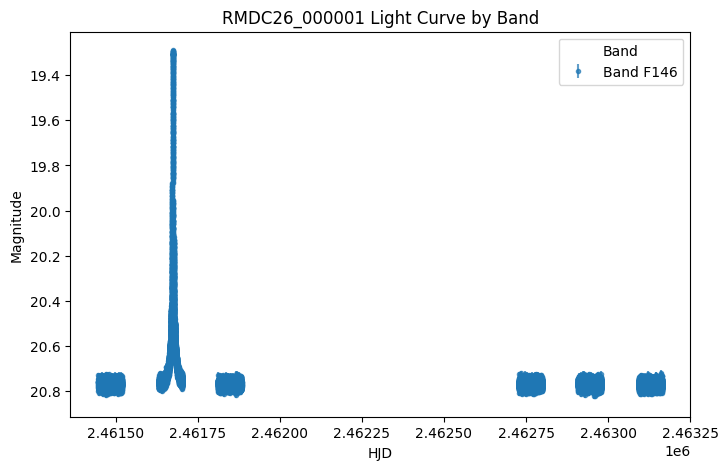

In [ ]:
# Get unique bands (`observatory_code` or `filt`)
bands = np.sort(np.unique(lc_data["filt"].to_numpy()))
print(f"Bands found: {bands}")
band = 'F146'
# Plot each band separately
plt.figure(figsize=(8, 5))
#for band in bands:
mask = lc_data["filt"] == band
plt.errorbar(
    lc_data["bjd"][mask], lc_data["mag"][mask], yerr=lc_data["mag_err"][mask],
    fmt=".", label=f"Band {band}", alpha=0.7
)

plt.gca().invert_yaxis()
plt.title(f"{EVENT_ID} Light Curve by Band")
plt.xlabel("HJD")
plt.ylabel("Magnitude")
plt.legend(title="Band")
plt.show()

In [ ]:
#create events and fit curve, save fit data (my_fit.fit_results["best_model"], ['chi2']) dictionary to a file
#file for each event
#no cropping